#  Clasificador de Vinos con KNN

En este notebook vamos a entrenar un modelo de **K-Vecinos más Cercanos (KNN)** para predecir la calidad de un vino tinto usando sus características químicas.

La idea es sencilla: dado un vino con ciertas propiedades (acidez, azúcar, alcohol...), el modelo va a decir si es de **baja, media o alta calidad**.

---

### Objetivos
1. Cargar y explorar el dataset de vinos
2. Entrenar un modelo KNN
3. Evaluar qué tan bien funciona
4. Encontrar el mejor valor de K
5. Crear una función que prediga la calidad de un vino nuevo

###  Dataset
Usamos el **Wine Quality Dataset** del UCI Machine Learning Repository. Cada fila es un vino con sus propiedades químicas, y la columna `quality` indica su calidad:
- `0` = Baja calidad
- `1` = Calidad media  
- `2` = Alta calidad

## 1.  Importar librerías

Primero traemos todo lo que vamos a necesitar.

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
plt.style.use('seaborn-v0_8-muted')
sns.set_palette('Set2')



## 2.  Cargar los datos

Descargamos el CSV directo desde GitHub.

In [155]:
# Cargamos el CSV
df = pd.read_csv("../data/raw/winequality-red.csv", sep=';')

In [156]:
df.shape

(1599, 12)

## 3.  Explorar el dataset

Vamos a echarle un vistazo para entender con qué estamos trabajando.

In [157]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [158]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [159]:
df.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [160]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Distribución de la variable objetivo (quality):
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


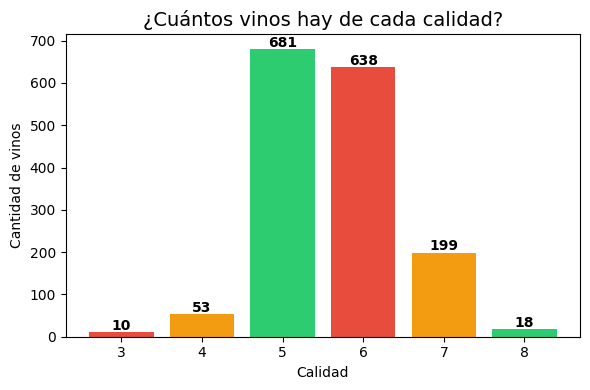

In [161]:
# ¿Cuántos vinos hay de cada clase?
print("Distribución de la variable objetivo (quality):")
print(df['quality'].value_counts())

# Gráfico de barras para verlo mejor
fig, ax = plt.subplots(figsize=(6, 4))

nombres = conteos.index.astype(str)
conteos = df['quality'].value_counts().sort_index()

ax.bar(nombres, conteos.values, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('¿Cuántos vinos hay de cada calidad?', fontsize=14)
ax.set_ylabel('Cantidad de vinos')
ax.set_xlabel('Calidad')

# Ponemos el número encima de cada barra
for i, v in enumerate(conteos.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4.  Visualizaciones rápidas

Antes de entrenar, vamos a ver cómo se relacionan algunas columnas con la calidad del vino.

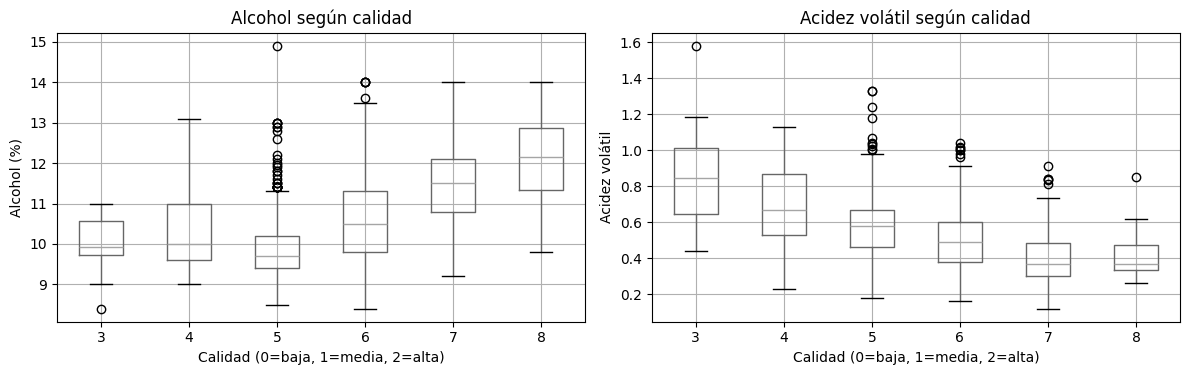

In [162]:
# Boxplot: alcohol vs calidad
# (Los vinos más ricos en alcohol, ¿tienen más calidad?)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: alcohol
df.boxplot(column='alcohol', by='quality', ax=axes[0])
axes[0].set_title('Alcohol según calidad')
axes[0].set_xlabel('Calidad (0=baja, 1=media, 2=alta)')
axes[0].set_ylabel('Alcohol (%)')

# Gráfico 2: volatile acidity
df.boxplot(column='volatile acidity', by='quality', ax=axes[1])
axes[1].set_title('Acidez volátil según calidad')
axes[1].set_xlabel('Calidad (0=baja, 1=media, 2=alta)')
axes[1].set_ylabel('Acidez volátil')

plt.suptitle('')  # Quitamos el título automático de boxplot
plt.tight_layout()
plt.show()



### los vinos de alta calidad tienden a tener MÁS alcohol y MENOS acidez volátil.

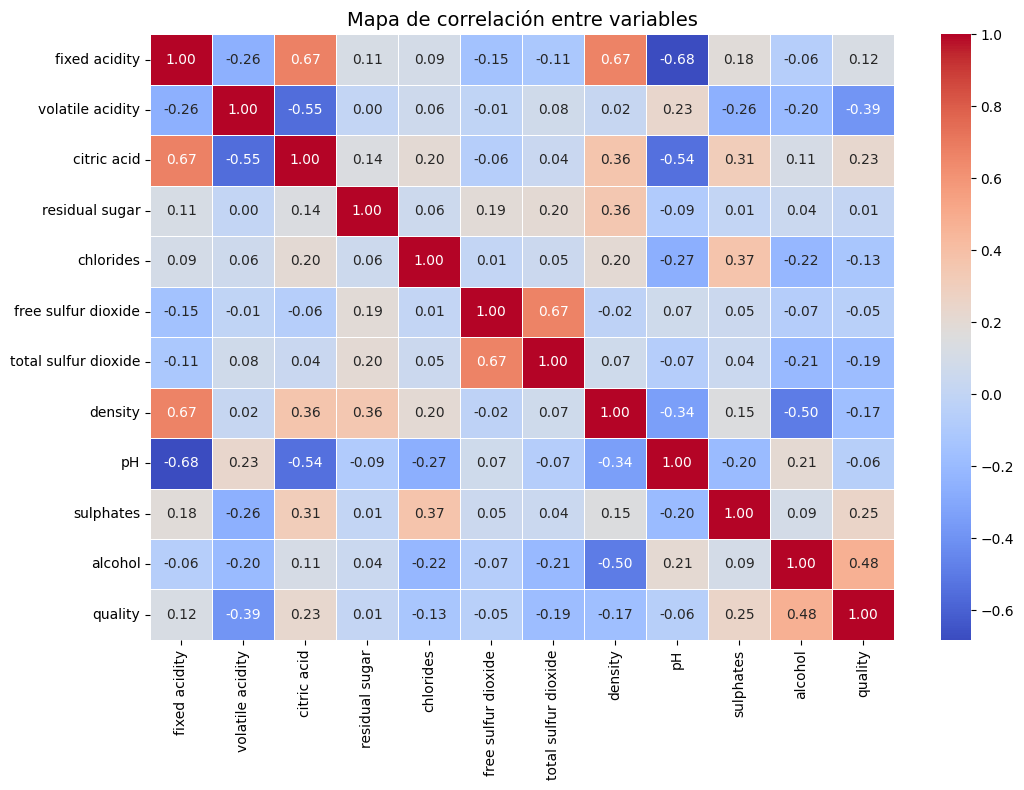

In [163]:
# Mapa de correlación entre variables
fig, ax = plt.subplots(figsize=(11, 8))

correlaciones = df.corr()

sns.heatmap(
    correlaciones,
    annot=True,       # Muestra los números
    fmt='.2f',        # Dos decimales
    cmap='coolwarm',  # Colores azul-rojo
    ax=ax,
    linewidths=0.5
)

ax.set_title('Mapa de correlación entre variables', fontsize=14)
plt.tight_layout()
plt.show()

## 5.  Separar datos y preparar el modelo

Aquí separamos las variables de entrada (X) del objetivo (y), dividimos en entrenamiento/prueba y escalamos los datos.

> **¿Por qué escalar?** KNN mide distancias entre puntos. Si una columna tiene valores entre 0 y 1 y otra entre 0 y 100, la segunda va a dominar. Escalar pone todo en la misma escala. 

In [164]:
X = df.drop(columns=['quality'])  
y = df['quality']                  

print(f"X tiene forma: {X.shape}   → {X.shape[0]} vinos, {X.shape[1]} características")
print(f"y tiene forma: {y.shape}   → {y.shape[0]} etiquetas de calidad")

X tiene forma: (1599, 11)   → 1599 vinos, 11 características
y tiene forma: (1599,)   → 1599 etiquetas de calidad


In [165]:
# Dividimos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} vinos")
print(f"Prueba:        {X_test.shape[0]} vinos")

Entrenamiento: 1279 vinos
Prueba:        320 vinos


In [166]:
# Escalamos los datos con StandardScaler
# fit_transform en entrenamiento, solo transform en prueba (el scaler aprende con train, no con test)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" Datos escalados correctamente")
print(f"Media de una columna antes de escalar: {X_train['alcohol'].mean():.2f}")
print(f"Media de esa columna después de escalar: {X_train_scaled[:, -1].mean():.4f} (aprox 0)")

 Datos escalados correctamente
Media de una columna antes de escalar: 10.42
Media de esa columna después de escalar: 0.0000 (aprox 0)


## 6. Entrenar el modelo KNN

Empezamos con `k=5` (5 vecinos más cercanos). Después vamos a probar otros valores.

In [167]:
# Creamos el modelo con k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenamos con los datos de entrenamiento
knn.fit(X_train_scaled, y_train)

print("Modelo entrenado con k=5")

Modelo entrenado con k=5


## 7.  Evaluar el modelo

Veamos qué tan bien predice el modelo con los datos de prueba.

In [168]:
# Hacemos predicciones con los datos de prueba
y_pred = knn.predict(X_test_scaled)

# Accuracy: % de vinos que clasificó bien
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy con k=5: {acc:.4f}  ({acc*100:.2f}% de vinos clasificados correctamente)")

Accuracy con k=5: 0.5469  (54.69% de vinos clasificados correctamente)


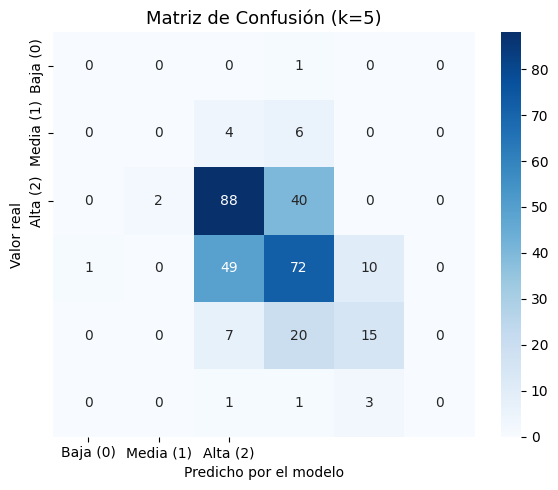

 La diagonal (de arriba-izq a abajo-der) son los aciertos.
   Lo que está fuera de la diagonal son los errores.


In [169]:
# Matriz de confusión: vemos dónde acierta y dónde se equivoca
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Baja (0)', 'Media (1)', 'Alta (2)'],
    yticklabels=['Baja (0)', 'Media (1)', 'Alta (2)'],
    ax=ax
)

ax.set_title('Matriz de Confusión (k=5)', fontsize=13)
ax.set_xlabel('Predicho por el modelo')
ax.set_ylabel('Valor real')

plt.tight_layout()
plt.show()

print(" La diagonal (de arriba-izq a abajo-der) son los aciertos.")
print("   Lo que está fuera de la diagonal son los errores.")

In [170]:
# Reporte completo de métricas
print("Reporte de clasificación:")
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=[str(c) for c in sorted(y_test.unique())]
))

print("\n Explicación rápida:")
print("   - precision: de los que dijo que eran clase X, ¿cuántos realmente lo eran?")
print("   - recall:    de los que realmente eran clase X, ¿cuántos detectó?")
print("   - f1-score:  promedio entre precision y recall")

Reporte de clasificación:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.59      0.68      0.63       130
           6       0.51      0.55      0.53       132
           7       0.54      0.36      0.43        42
           8       0.00      0.00      0.00         5

    accuracy                           0.55       320
   macro avg       0.27      0.26      0.26       320
weighted avg       0.52      0.55      0.53       320


 Explicación rápida:
   - precision: de los que dijo que eran clase X, ¿cuántos realmente lo eran?
   - recall:    de los que realmente eran clase X, ¿cuántos detectó?
   - f1-score:  promedio entre precision y recall


/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 8.  Optimización de K

¿Es k=5 el mejor valor? Vamos a probarlo con distintos valores de k y ver cuál da mejor accuracy.

In [171]:
# Probamos valores de k del 1 al 20
valores_k = range(1, 21)
accuracies = []

for k in valores_k:
    # Creamos y entrenamos el modelo con este k
    modelo_temp = KNeighborsClassifier(n_neighbors=k)
    modelo_temp.fit(X_train_scaled, y_train)

    # Predecimos y guardamos el accuracy
    pred_temp = modelo_temp.predict(X_test_scaled)
    acc_temp = accuracy_score(y_test, pred_temp)
    accuracies.append(acc_temp)

    print(f"k={k:2d} → Accuracy: {acc_temp:.4f}")

k= 1 → Accuracy: 0.6219
k= 2 → Accuracy: 0.5375
k= 3 → Accuracy: 0.5156
k= 4 → Accuracy: 0.5406
k= 5 → Accuracy: 0.5469
k= 6 → Accuracy: 0.5563
k= 7 → Accuracy: 0.5500
k= 8 → Accuracy: 0.5594


k= 9 → Accuracy: 0.5594
k=10 → Accuracy: 0.5875
k=11 → Accuracy: 0.5719
k=12 → Accuracy: 0.5656
k=13 → Accuracy: 0.5687
k=14 → Accuracy: 0.5656
k=15 → Accuracy: 0.5563
k=16 → Accuracy: 0.5625
k=17 → Accuracy: 0.5531
k=18 → Accuracy: 0.5500
k=19 → Accuracy: 0.5156
k=20 → Accuracy: 0.5375


In [172]:
# Encontramos el mejor k
mejor_k = valores_k[accuracies.index(max(accuracies))]
mejor_acc = max(accuracies)

print(f"🏆 Mejor k: {mejor_k} con accuracy de {mejor_acc:.4f} ({mejor_acc*100:.2f}%)")

🏆 Mejor k: 1 con accuracy de 0.6219 (62.19%)


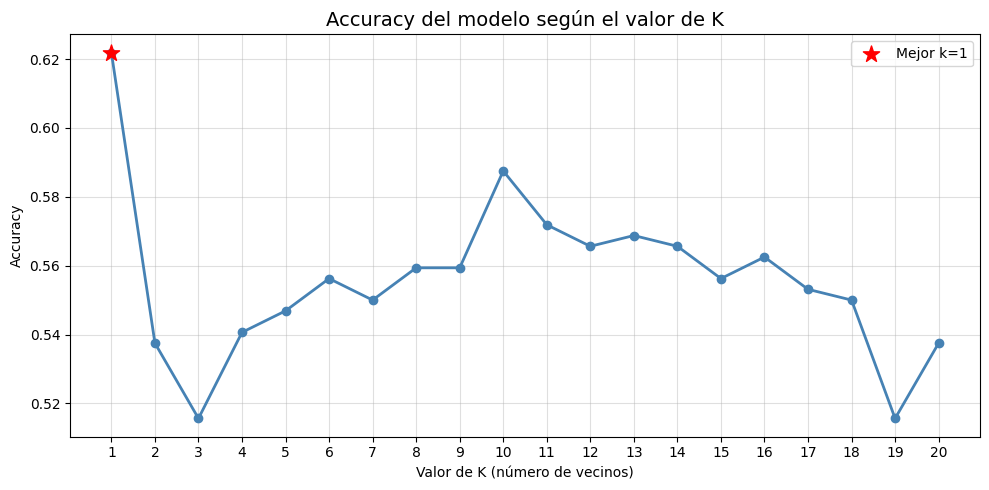

In [173]:
# Gráfico de accuracy vs k
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(valores_k, accuracies, marker='o', color='steelblue', linewidth=2, markersize=6)

# Marcamos el mejor k con una estrella roja
ax.scatter(mejor_k, mejor_acc, color='red', zorder=5, s=150, marker='*', label=f'Mejor k={mejor_k}')

ax.set_title('Accuracy del modelo según el valor de K', fontsize=14)
ax.set_xlabel('Valor de K (número de vecinos)')
ax.set_ylabel('Accuracy')
ax.set_xticks(list(valores_k))
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 9.  Entrenamos el modelo final con el mejor K

Ahora que sabemos cuál es el mejor valor de k, entrenamos el modelo final.

In [174]:
# Entrenamos el modelo final con el mejor k que encontramos
knn_final = KNeighborsClassifier(n_neighbors=mejor_k)
knn_final.fit(X_train_scaled, y_train)

# Evaluamos una última vez
y_pred_final = knn_final.predict(X_test_scaled)
acc_final = accuracy_score(y_test, y_pred_final)

print(f"Modelo final entrenado con k={mejor_k}")
print(f" Accuracy final: {acc_final:.4f} ({acc_final*100:.2f}%)")

Modelo final entrenado con k=1
 Accuracy final: 0.6219 (62.19%)


## 10.  Función para predecir la calidad de un vino

Creamos una función que recibe los valores de un vino nuevo y nos dice su calidad.

In [175]:
def predict_wine_quality(valores_vino):
    """
    Predice la calidad de un vino a partir de sus características químicas.

    Parámetros:
    -----------
    valores_vino : lista con 11 valores en este orden:
        [fixed acidity, volatile acidity, citric acid, residual sugar,
         chlorides, free sulfur dioxide, total sulfur dioxide,
         density, pH, sulphates, alcohol]

    Retorna:
    --------
    Un mensaje con la predicción de calidad.
    """

    # Convertimos la lista a un array de numpy con la forma correcta

    vino_array = np.array(valores_vino).reshape(1, -1)

  
    vino_scaled = scaler.transform(vino_array)

    # Hacemos la predicción
    prediccion = knn_final.predict(vino_scaled)[0]

    # Convertimos el número a un mensaje legible
    if prediccion == 0:
        return "Este vino probablemente sea de baja calidad "
    elif prediccion == 1:
        return "Este vino probablemente sea de calidad media "
    else:
        return "¡Este vino es de alta calidad! 🥂✨"


In [176]:
# Probamos la función con el ejemplo del enunciado
resultado = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print(resultado)

¡Este vino es de alta calidad! 🥂✨


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [177]:
# Probamos con otro vino inventado (uno con más alcohol y menos acidez)
vino_top = [7.0, 0.3, 0.4, 2.5, 0.055, 15.0, 40.0, 0.9960, 3.35, 0.80, 12.5]
print("Vino con buen alcohol y poca acidez:")
print(predict_wine_quality(vino_top))

Vino con buen alcohol y poca acidez:
¡Este vino es de alta calidad! 🥂✨


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [178]:
# Y uno que seguramente sea malo (mucha acidez volátil, poco alcohol)
vino_malo = [8.5, 1.1, 0.0, 3.0, 0.12, 5.0, 60.0, 0.9990, 3.80, 0.40, 8.0]
print("Vino con mucha acidez y poco alcohol:")
print(predict_wine_quality(vino_malo))

Vino con mucha acidez y poco alcohol:
¡Este vino es de alta calidad! 🥂✨


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 11.  Conclusiones



In [179]:
print("=" * 55)
print("          RESUMEN DEL PROYECTO")
print("=" * 55)
print(f"  Dataset:           {df.shape[0]} vinos, {df.shape[1]} columnas")
print(f"  Mejor valor de K:  {mejor_k}")
print(f"  Accuracy final:    {acc_final*100:.2f}%")
print("=" * 55)

          RESUMEN DEL PROYECTO
  Dataset:           1599 vinos, 12 columnas
  Mejor valor de K:  1
  Accuracy final:    62.19%


### ¿Qué aprendimos?

- **KNN** es un algoritmo sencillo pero efectivo para clasificación. Simplemente busca los k ejemplos más parecidos al nuevo dato y vota.

- **Escalar los datos es clave** con KNN porque trabaja con distancias. Sin escalar, columnas con valores grandes dominarían la predicción.

- **El alcohol y la acidez volátil** son las características más correlacionadas con la calidad del vino. Los buenos vinos tienden a tener más alcohol y menos acidez volátil.

- **Optimizar K** vale la pena: probar varios valores y elegir el mejor mejora el rendimiento del modelo.

- La IA puede actuar como **sommelier digital** 🍷, analizando las propiedades químicas de un vino para estimar su calidad sin ni siquiera probarlo.



# Guardamos modelo 

In [181]:
joblib.dump(knn, "../models/scaler_wine.pkl")
joblib.dump(knn_final , "../models/knn_wine_final.pkl")  


['../models/knn_wine_final.pkl']